In [ ]:
# ── 0. IMPORTS ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder


In [ ]:
# ── 1. LOAD DATASET ──────────────────────────────────────────
df = pd.read_csv('/content/diet_recommendations_dataset.csv')

print("Shape:", df.shape)
df.head()


Shape: (1000, 20)


,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Dietary_Restrictions,Allergies,Preferred_Cuisine,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Diet_Recommendation
0,P0001,56,Male,58.4,160,22.8,Obesity,Moderate,Moderate,3079,173.3,133,116.3,NaN,Peanuts,Mexican,3.1,96.6,3.1,Balanced
1,P0002,69,Male,101.2,169,35.4,Diabetes,Mild,Moderate,3032,199.2,120,137.1,NaN,Peanuts,Chinese,4.5,63.2,0.6,Low_Carb
2,P0003,46,Female,63.5,173,21.2,Hypertension,Mild,Sedentary,1737,181.0,121,109.6,NaN,Peanuts,Chinese,3.8,57.5,4.6,Low_Sodium
3,P0004,32,Male,58.1,164,21.6,NaN,Mild,Moderate,2657,168.2,144,159.4,NaN,NaN,Mexican,4.3,54.5,0.4,Balanced
4,P0005,60,Male,79.5,197,20.5,Diabetes,Moderate,Sedentary,3496,200.4,172,182.3,Low_Sugar,NaN,Italian,9.8,78.2,4.7,Low_Carb


In [ ]:
# ── 2. INITIAL EXPLORATION ───────────────────────────────────
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        1000 non-null   object 
 1   Age                               1000 non-null   int64  
 2   Gender                            1000 non-null   object 
 3   Weight_kg                         1000 non-null   float64
 4   Height_cm                         1000 non-null   int64  
 5   BMI                               1000 non-null   float64
 6   Disease_Type                      796 non-null    object 
 7   Severity                          1000 non-null   object 
 8   Physical_Activity_Level           1000 non-null   object 
 9   Daily_Caloric_Intake              1000 non-null   int64  
 10  Cholesterol_mg/dL                 1000 non-null   float64
 11  Blood_Pressure_mmHg               1000 non-null   int64  
 12  Glucose

,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,49.857000,84.602400,174.81700,28.191600,2475.064000,199.717900,144.993000,136.867600,5.166000,74.88430,2.469200
std,18.114267,20.088121,14.33377,8.040136,565.017032,29.080614,20.245712,37.934819,2.847995,14.82638,1.459631
min,18.000000,50.000000,150.00000,13.000000,1500.000000,150.400000,110.000000,70.200000,0.000000,50.00000,0.000000
25%,35.000000,66.600000,162.00000,22.075000,1984.750000,174.300000,128.000000,105.000000,2.800000,62.00000,1.200000
50%,50.000000,85.200000,175.00000,27.450000,2470.500000,199.850000,145.000000,138.000000,5.200000,74.20000,2.400000
75%,66.000000,102.000000,187.00000,33.425000,2937.250000,224.850000,163.000000,170.650000,7.600000,88.20000,3.700000
max,79.000000,119.700000,199.00000,52.400000,3498.000000,249.900000,179.000000,200.000000,10.000000,100.00000,5.000000


In [ ]:
# Separate column types
numerical_columns = df.select_dtypes(include='number').columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()
categorical_columns.remove('Patient_ID')
categorical_columns.remove('Diet_Recommendation')


In [ ]:
print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)


Numerical columns: ['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan', 'Dietary_Nutrient_Imbalance_Score']
Categorical columns: ['Gender', 'Disease_Type', 'Severity', 'Physical_Activity_Level', 'Dietary_Restrictions', 'Allergies', 'Preferred_Cuisine']


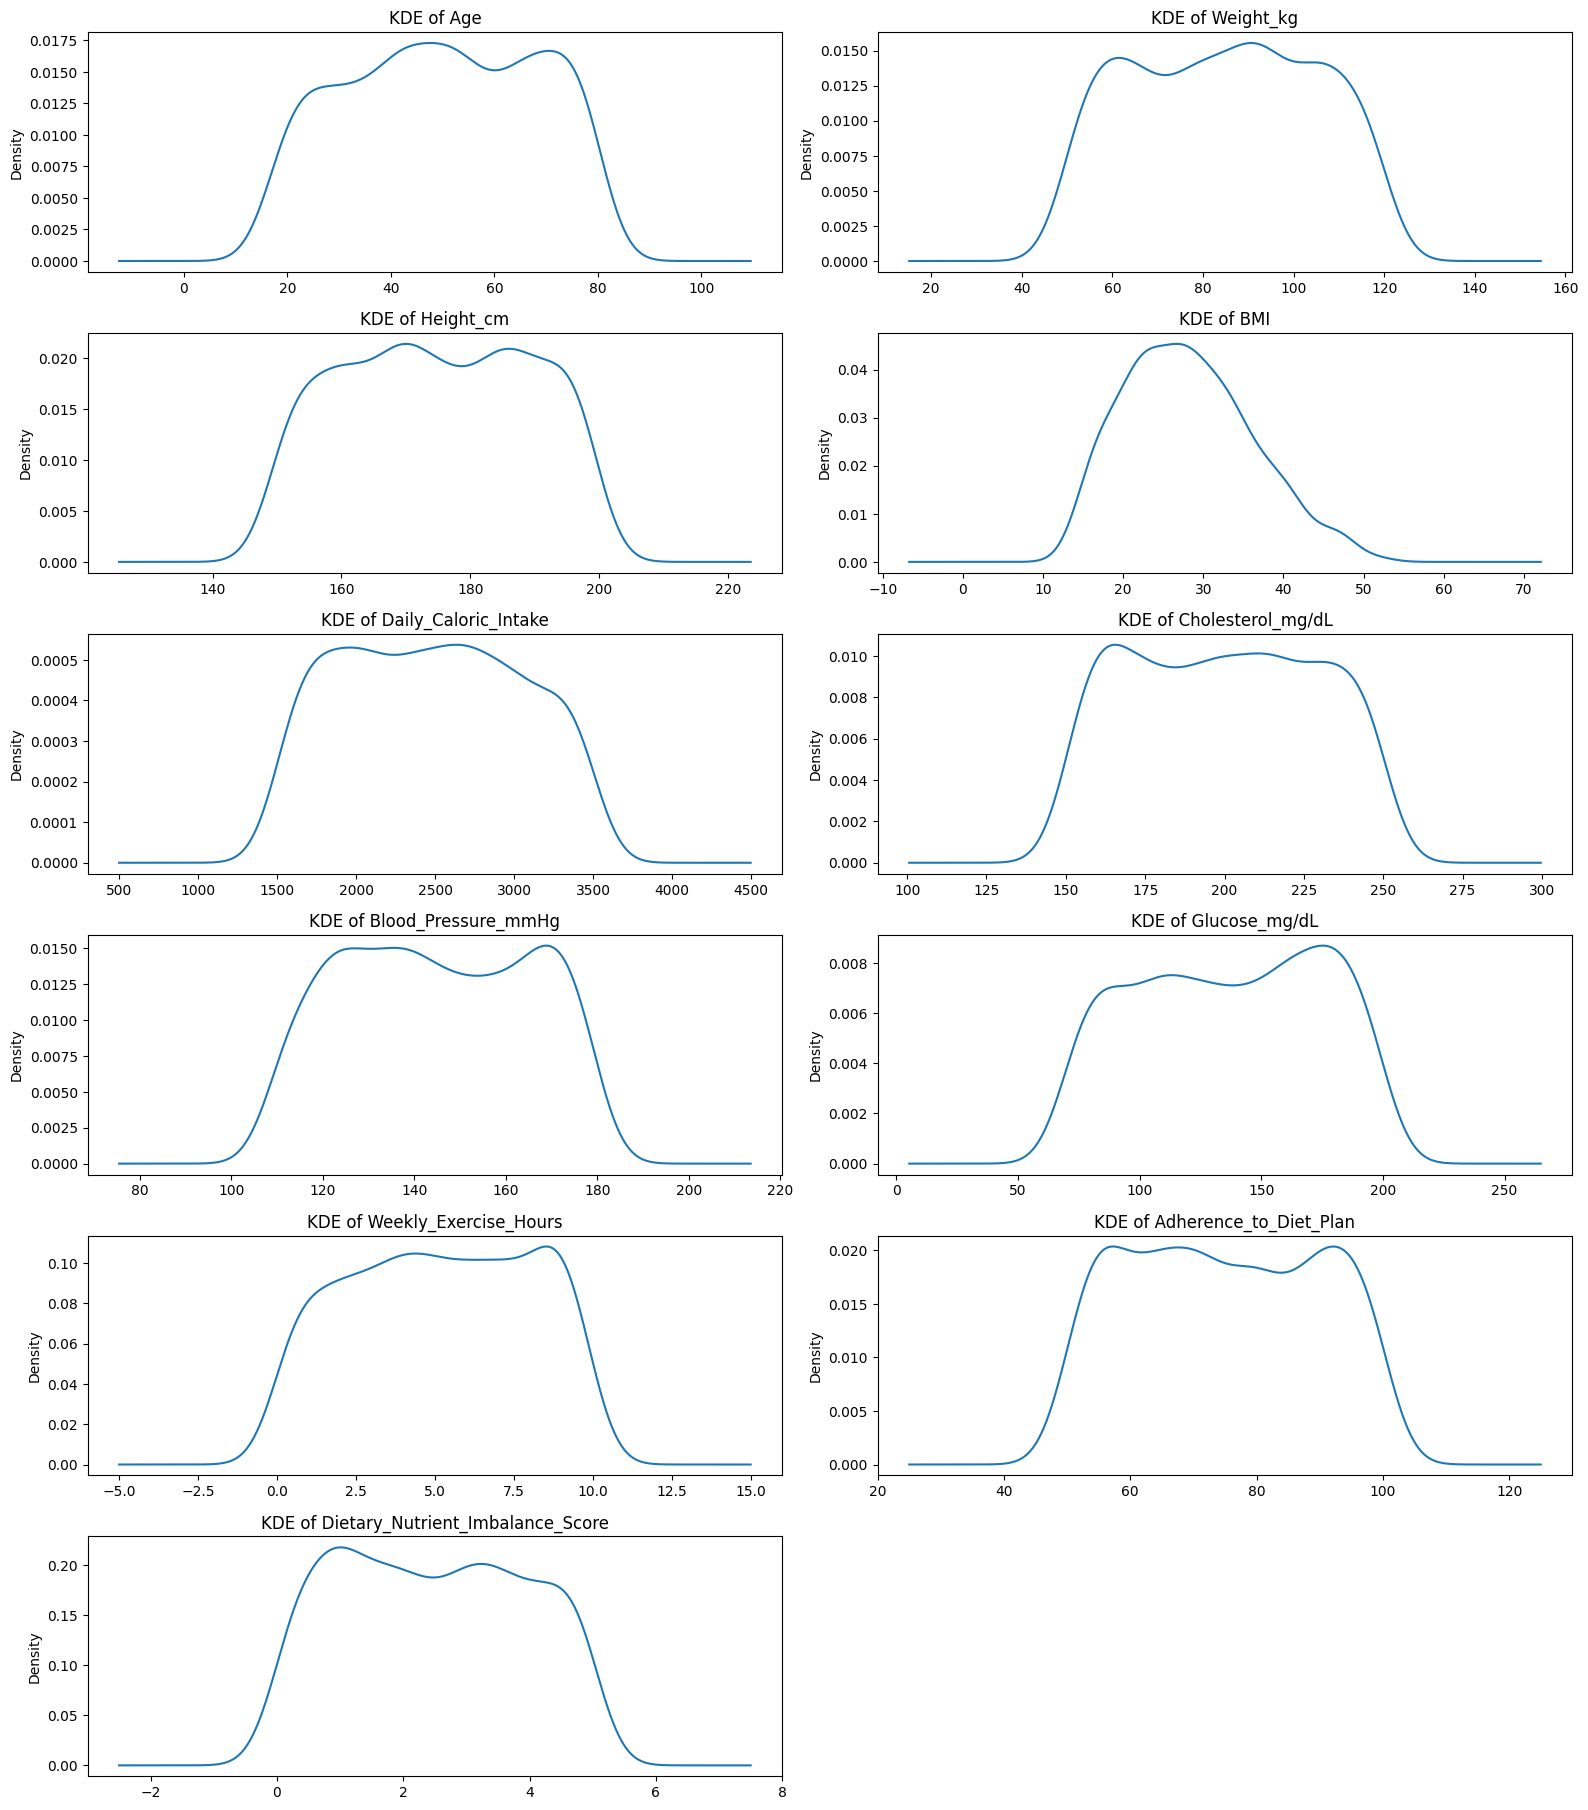

In [ ]:
# ── 3. DATA VISUALIZATION ────────────────────────────────────

# 3a. KDE plots for numerical features
plt.figure(figsize=(16, 30))
for i, col in enumerate(numerical_columns):
    plt.subplot(10, 2, i + 1)
    df[col].plot(kind='kde')
    plt.title(f"KDE of {col}")
plt.tight_layout()
plt.show()

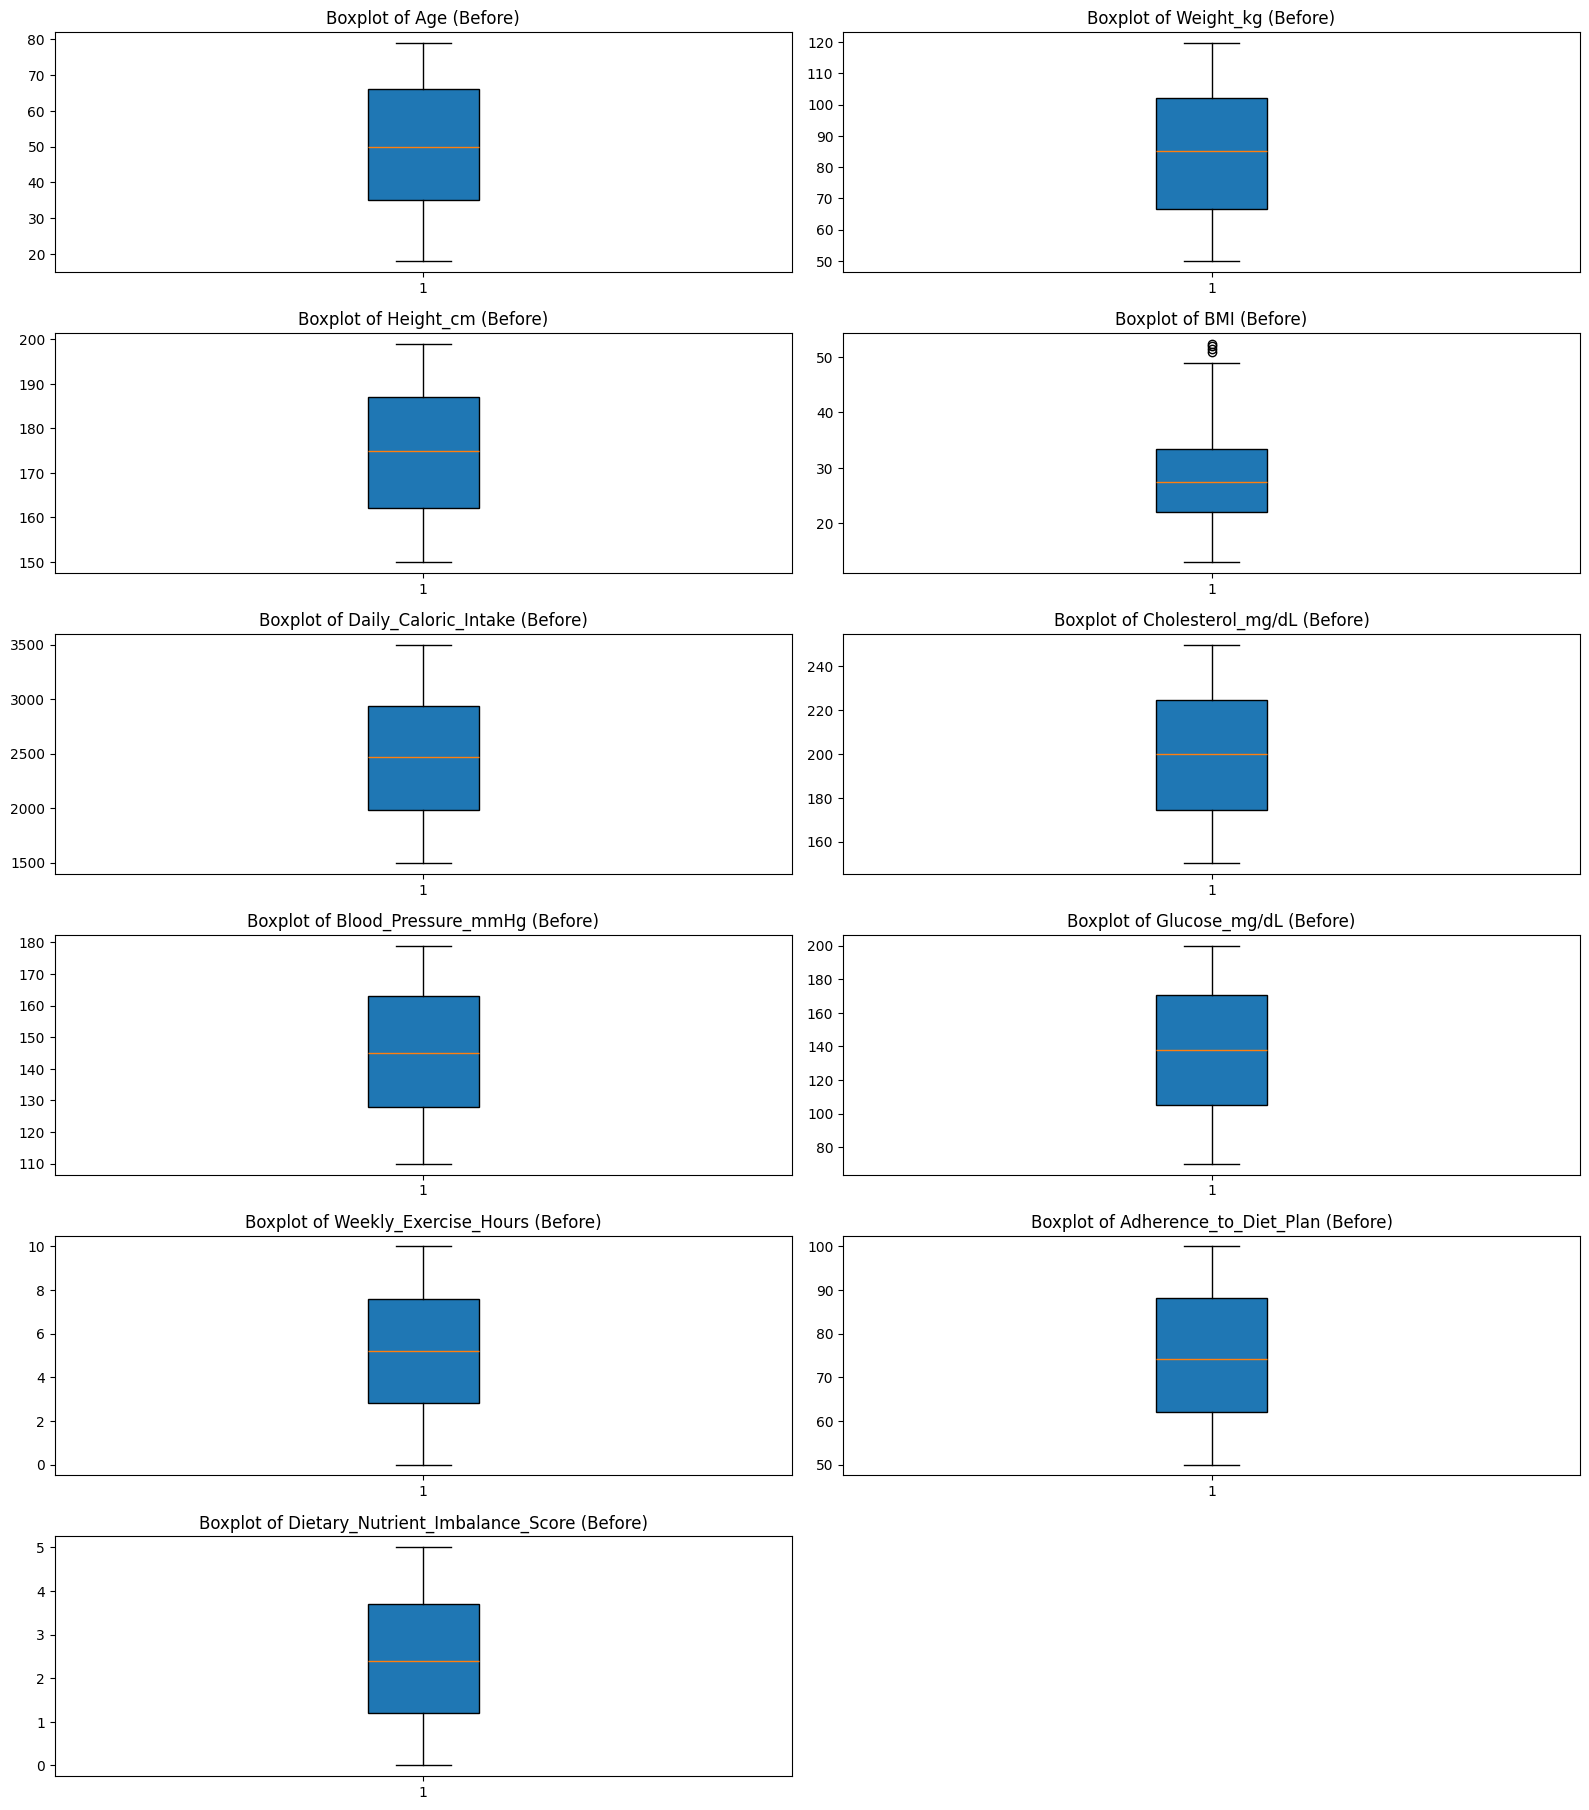

In [ ]:
# 3b. Boxplots BEFORE outlier removal
plt.figure(figsize=(16, 30))
for i, col in enumerate(numerical_columns):
    plt.subplot(10, 2, i + 1)
    plt.boxplot(df[col].dropna(), patch_artist=True)
    plt.title(f"Boxplot of {col} (Before)")
plt.tight_layout()
plt.show()

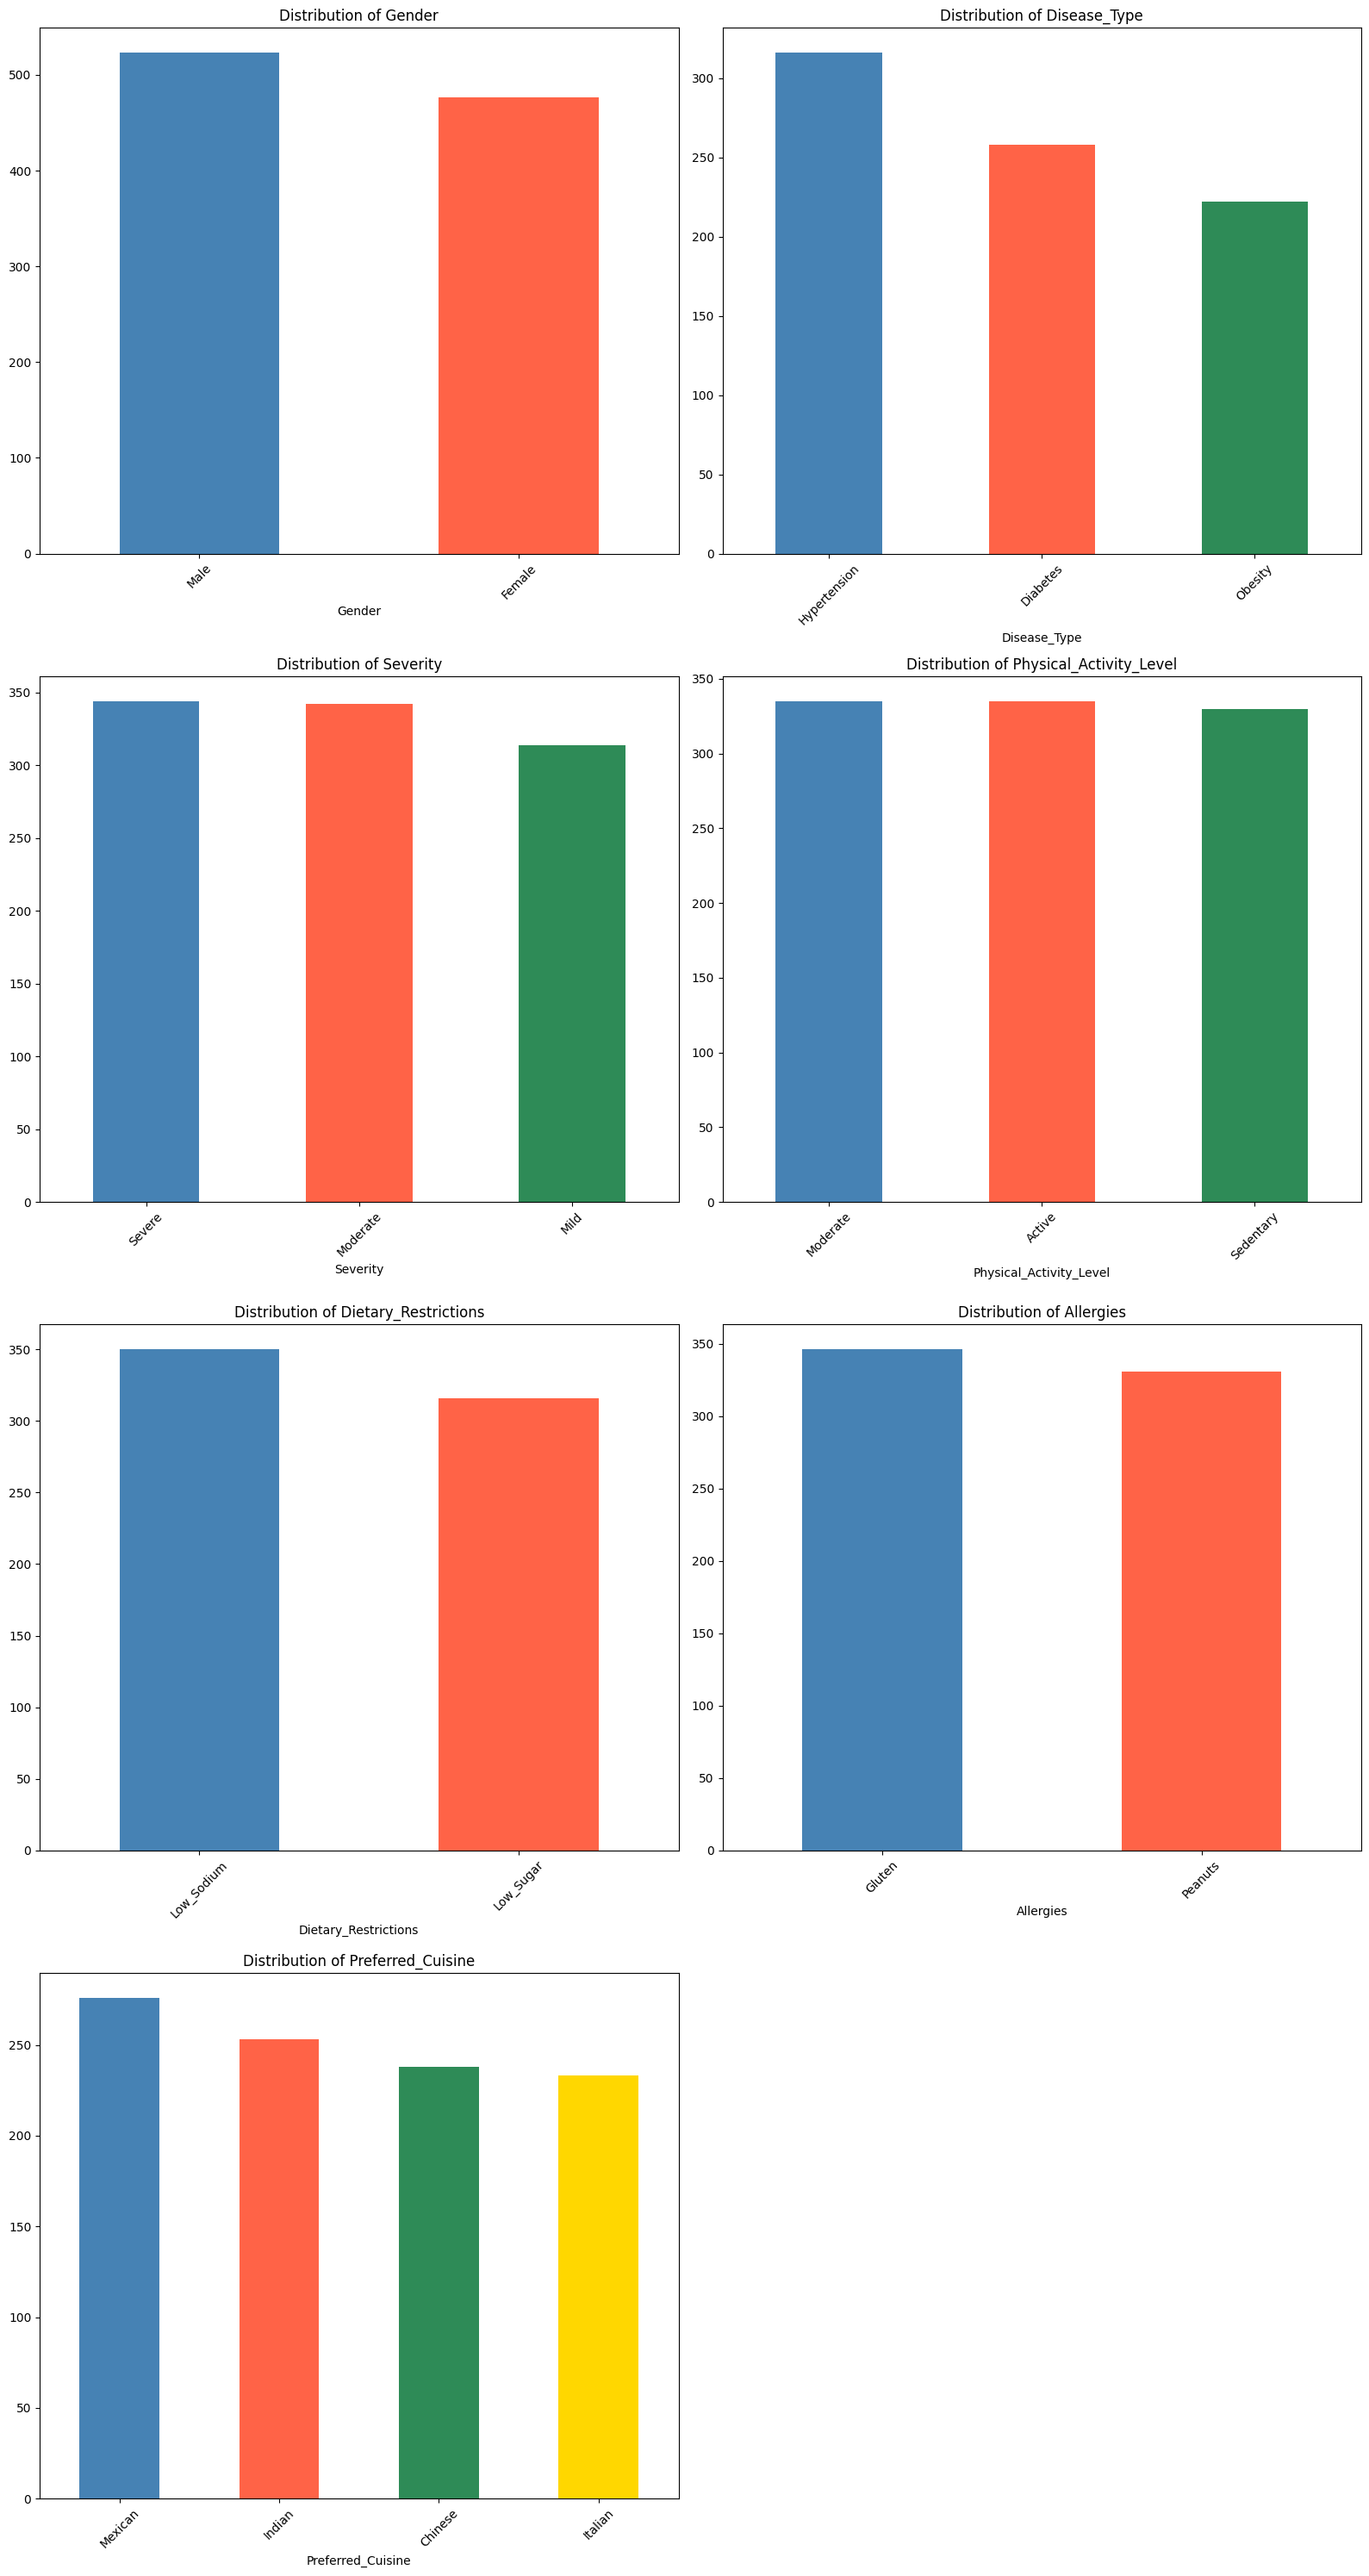

In [ ]:
# 3c. Bar charts for categorical features
plt.figure(figsize=(16, 30))
for i, col in enumerate(categorical_columns):
    plt.subplot(4, 2, i + 1)
    df[col].value_counts().plot.bar(rot=45, color=['steelblue', 'tomato', 'seagreen', 'gold'])
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

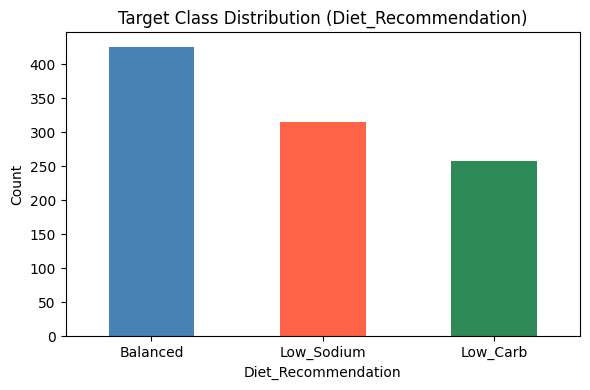

Class counts:
 Diet_Recommendation
Balanced      426
Low_Sodium    316
Low_Carb      258
Name: count, dtype: int64

Class percentages:
 Diet_Recommendation
Balanced      42.6
Low_Sodium    31.6
Low_Carb      25.8
Name: proportion, dtype: float64


In [ ]:
# 3d. Target class distribution
plt.figure(figsize=(6, 4))
df['Diet_Recommendation'].value_counts().plot.bar(color=['steelblue', 'tomato', 'seagreen'], rot=0)
plt.title("Target Class Distribution (Diet_Recommendation)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


print("Class counts:\n", df['Diet_Recommendation'].value_counts())
print("\nClass percentages:\n", df['Diet_Recommendation'].value_counts(normalize=True) * 100)

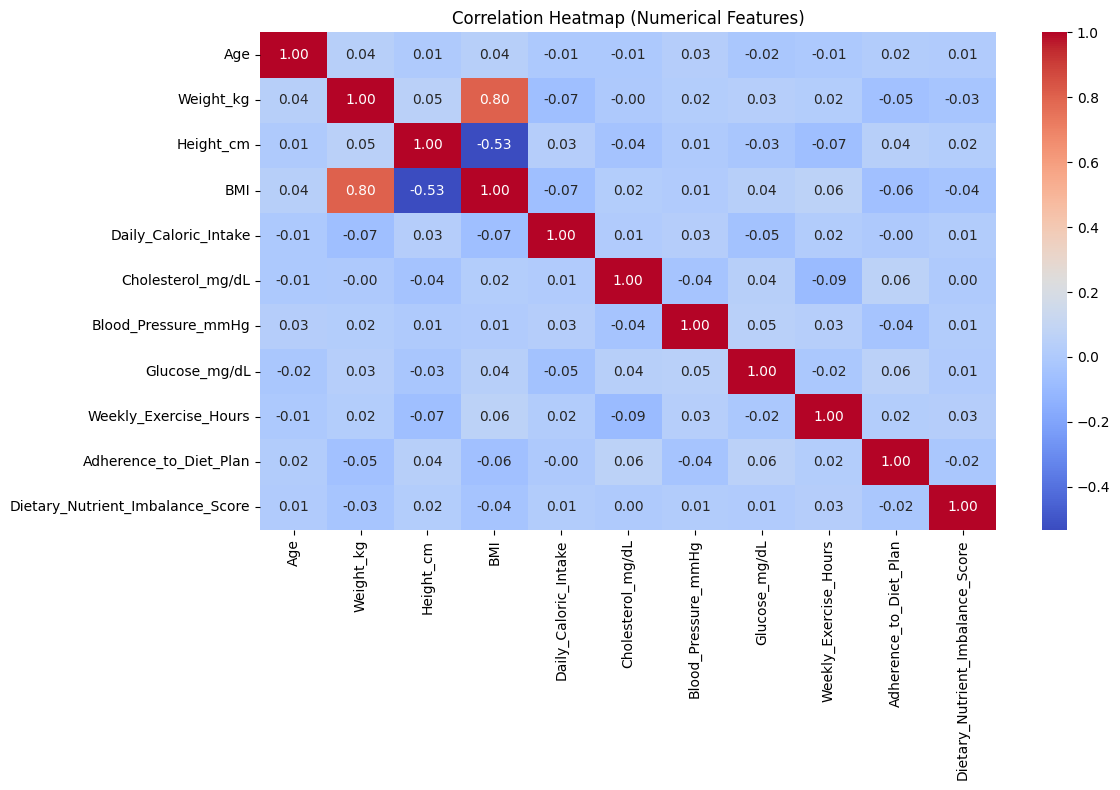

In [ ]:
# 3e. Correlation heatmap (numerical features)
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

In [ ]:
# 3f. Cross-tabulation: categorical features vs target
for col in categorical_columns:
    cross_tab = pd.crosstab(df[col], df['Diet_Recommendation'])
    print(f"\nCross-tab: {col} vs Diet_Recommendation")
    display(cross_tab)


Cross-tab: Gender vs Diet_Recommendation


Diet_Recommendation,Balanced,Low_Carb,Low_Sodium
Gender,,,
Female,213,113,151
Male,213,145,165



Cross-tab: Disease_Type vs Diet_Recommendation


Diet_Recommendation,Balanced,Low_Carb,Low_Sodium
Disease_Type,,,
Diabetes,0,258,0
Hypertension,0,0,316
Obesity,222,0,0



Cross-tab: Severity vs Diet_Recommendation


...

Diet_Recommendation,Balanced,Low_Carb,Low_Sodium
Dietary_Restrictions,,,
Low_Sodium,134,105,111
Low_Sugar,132,68,116



Cross-tab: Allergies vs Diet_Recommendation


Diet_Recommendation,Balanced,Low_Carb,Low_Sodium
Allergies,,,
Gluten,163,76,107
Peanuts,133,90,108



Cross-tab: Preferred_Cuisine vs Diet_Recommendation


Diet_Recommendation,Balanced,Low_Carb,Low_Sodium
Preferred_Cuisine,,,
Chinese,112,56,70
Indian,94,70,89
Italian,105,59,69
Mexican,115,73,88


In [ ]:
# ── 4. DATA PREPROCESSING ────────────────────────────────────

# 4a. Check missing values
print("Missing values before:\n", df.isnull().sum())


Missing values before:
 Patient_ID                            0
Age                                   0
Gender                                0
Weight_kg                             0
Height_cm                             0
BMI                                   0
Disease_Type                        204
Severity                              0
Physical_Activity_Level               0
Daily_Caloric_Intake                  0
Cholesterol_mg/dL                     0
Blood_Pressure_mmHg                   0
Glucose_mg/dL                         0
Dietary_Restrictions                334
Allergies                           323
Preferred_Cuisine                     0
Weekly_Exercise_Hours                 0
Adherence_to_Diet_Plan                0
Dietary_Nutrient_Imbalance_Score      0
Diet_Recommendation                   0
dtype: int64


In [ ]:
# 4b. Fill missing categorical values with mode
df[categorical_columns] = df[categorical_columns].fillna(
    df[categorical_columns].mode().iloc[0]
)

# Fill missing numerical values (if any) with median
df[numerical_columns] = df[numerical_columns].fillna(
    df[numerical_columns].median()
)

print("\nMissing values after:\n", df.isnull().sum())


Missing values after:
 Patient_ID                          0
Age                                 0
Gender                              0
Weight_kg                           0
Height_cm                           0
BMI                                 0
Disease_Type                        0
Severity                            0
Physical_Activity_Level             0
Daily_Caloric_Intake                0
Cholesterol_mg/dL                   0
Blood_Pressure_mmHg                 0
Glucose_mg/dL                       0
Dietary_Restrictions                0
Allergies                           0
Preferred_Cuisine                   0
Weekly_Exercise_Hours               0
Adherence_to_Diet_Plan              0
Dietary_Nutrient_Imbalance_Score    0
Diet_Recommendation                 0
dtype: int64


In [ ]:
# 4c. Outlier detection and capping (IQR method)
print("\nOutlier counts before capping:")
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col}: {n_outliers} outliers")

# Cap outliers
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)


Outlier counts before capping:
  Age: 0 outliers
  Weight_kg: 0 outliers
  Height_cm: 0 outliers
  BMI: 4 outliers
  Daily_Caloric_Intake: 0 outliers
  Cholesterol_mg/dL: 0 outliers
  Blood_Pressure_mmHg: 0 outliers
  Glucose_mg/dL: 0 outliers
  Weekly_Exercise_Hours: 0 outliers
  Adherence_to_Diet_Plan: 0 outliers
  Dietary_Nutrient_Imbalance_Score: 0 outliers


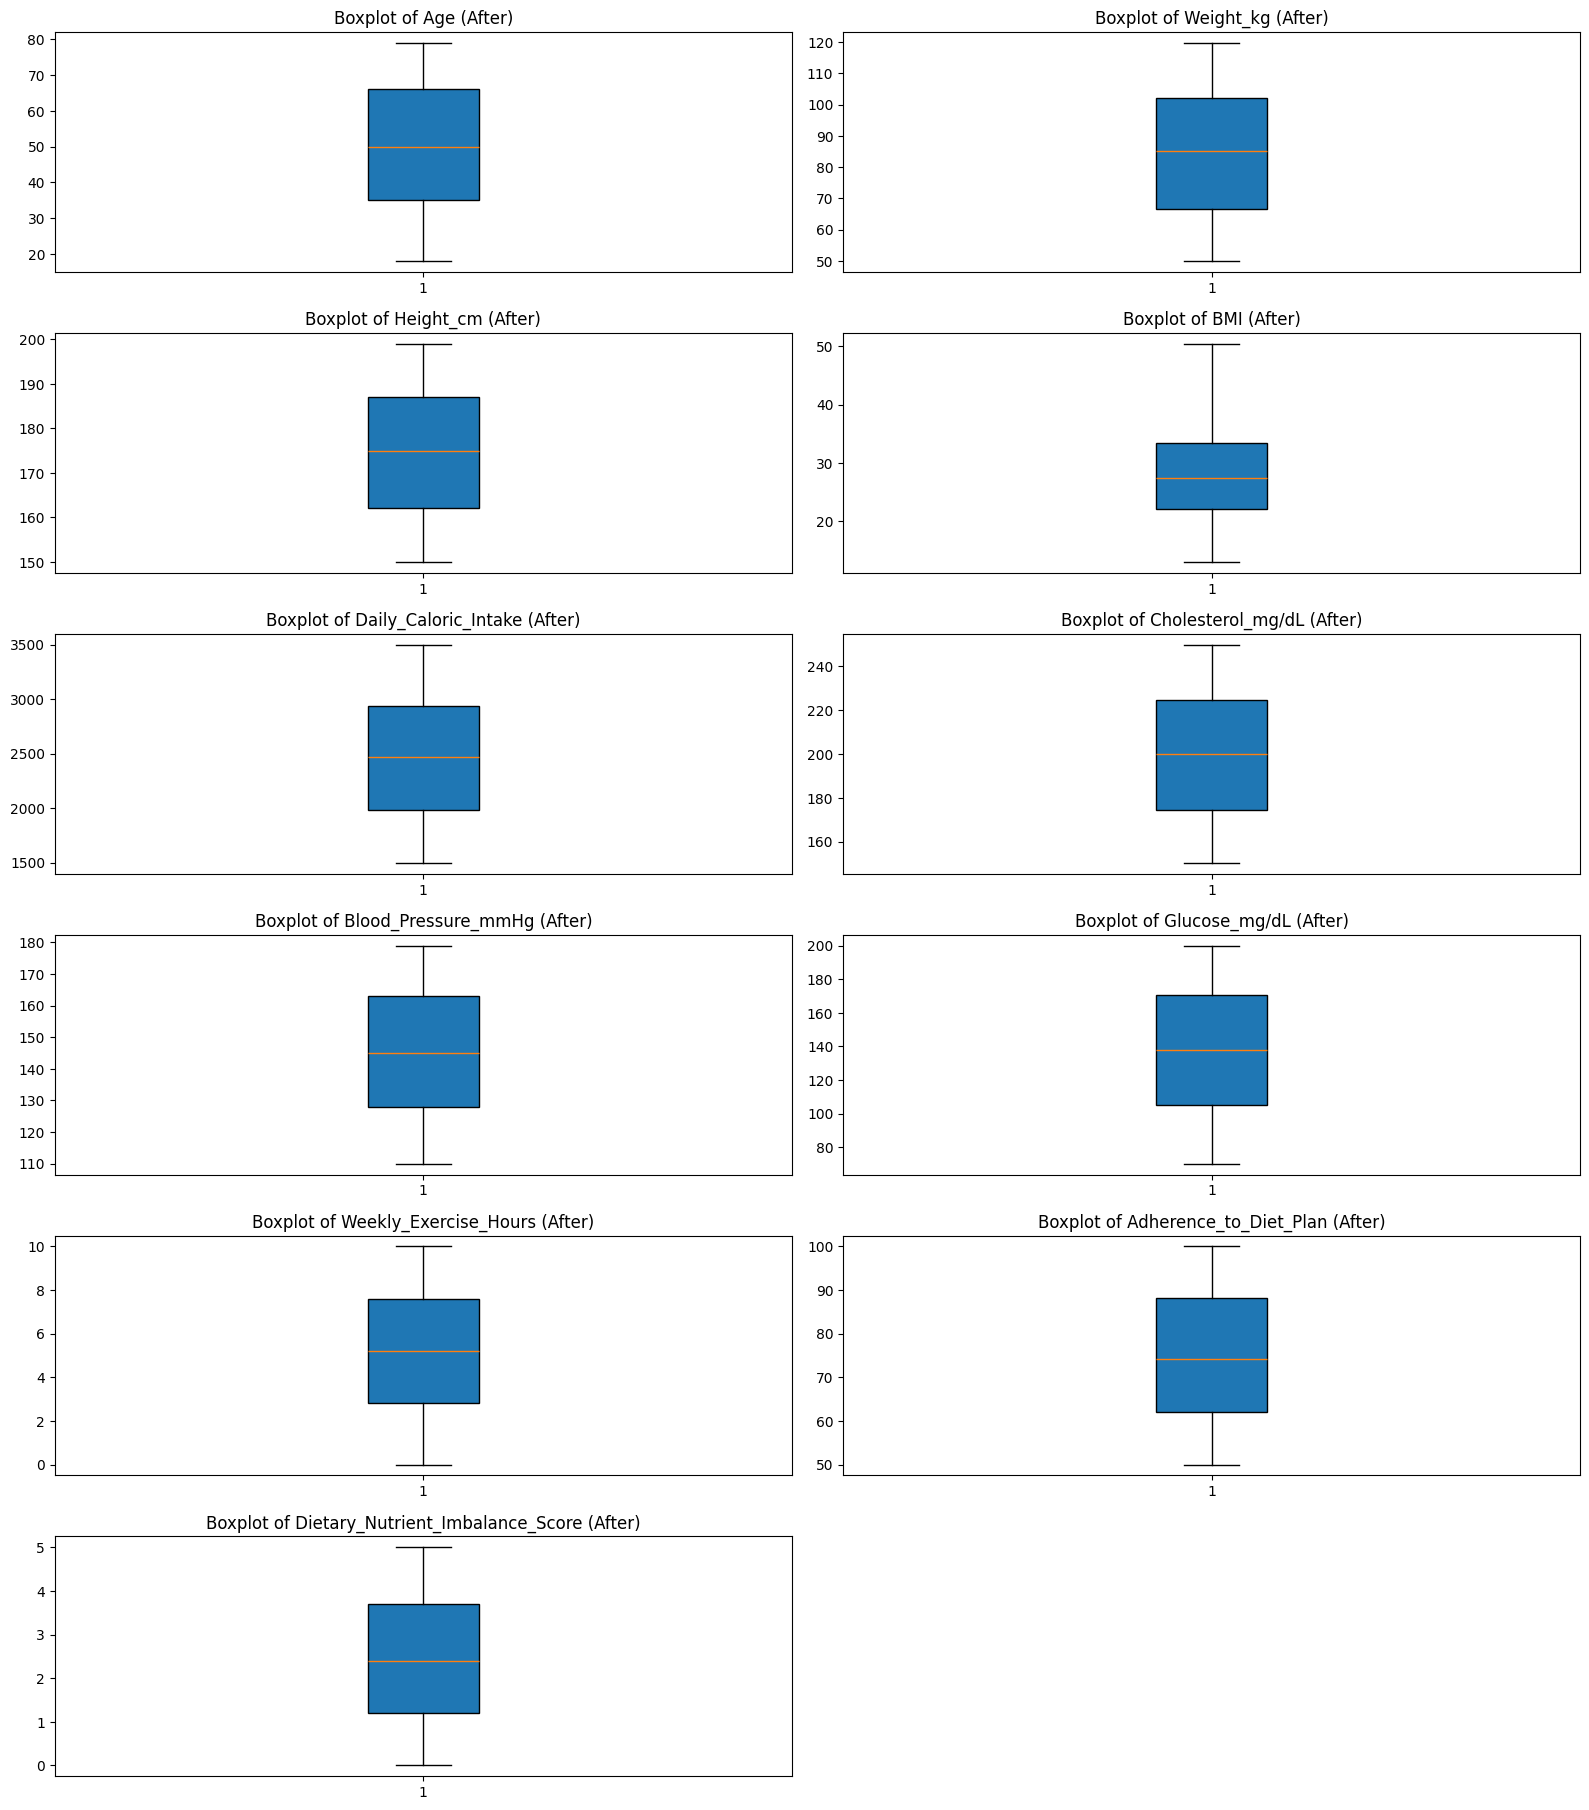

In [ ]:
# 4d. Boxplots AFTER outlier capping
plt.figure(figsize=(16, 30))
for i, col in enumerate(numerical_columns):
    plt.subplot(10, 2, i + 1)
    plt.boxplot(df[col].dropna(), patch_artist=True)
    plt.title(f"Boxplot of {col} (After)")
plt.tight_layout()
plt.show()

In [ ]:
# 4e. Drop Patient_ID (not a feature)
df.drop(columns=['Patient_ID'], inplace=True)

In [ ]:
# 4f. Label encode the TARGET column (y)
le = LabelEncoder()
df['Diet_Recommendation'] = le.fit_transform(df['Diet_Recommendation'])
print("\nTarget encoding mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")


Target encoding mapping:
  Balanced → 0
  Low_Carb → 1
  Low_Sodium → 2


In [ ]:
# 4g. One-Hot encode remaining categorical features (X)
df = pd.get_dummies(df, columns=categorical_columns, drop_first=False)
print("\nShape after encoding:", df.shape)
print("Final columns:", df.columns.tolist())


Shape after encoding: (1000, 31)
Final columns: ['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan', 'Dietary_Nutrient_Imbalance_Score', 'Diet_Recommendation', 'Gender_Female', 'Gender_Male', 'Disease_Type_Diabetes', 'Disease_Type_Hypertension', 'Disease_Type_Obesity', 'Severity_Mild', 'Severity_Moderate', 'Severity_Severe', 'Physical_Activity_Level_Active', 'Physical_Activity_Level_Moderate', 'Physical_Activity_Level_Sedentary', 'Dietary_Restrictions_Low_Sodium', 'Dietary_Restrictions_Low_Sugar', 'Allergies_Gluten', 'Allergies_Peanuts', 'Preferred_Cuisine_Chinese', 'Preferred_Cuisine_Indian', 'Preferred_Cuisine_Italian', 'Preferred_Cuisine_Mexican']


In [ ]:
# 4h. Normalize numerical features (MinMaxScaler)
scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [ ]:
# ── 5. FINAL X / y SPLIT ─────────────────────────────────────
X = df.drop(columns=['Diet_Recommendation'])
y = df['Diet_Recommendation']

print("\n✅ Phase 1 Complete!")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"   y classes: {y.unique()}")


✅ Phase 1 Complete!
   X shape: (1000, 30)
   y shape: (1000,)
   y classes: [0 1 2]


In [ ]:
# ── 0. IMPORTS ───────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# ── 1. TRAIN / TEST SPLIT ────────────────────────────────────
# 80% training, 20% testing | stratify keeps class ratios balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing set size  : {X_test.shape[0]} samples")

Training set size : 800 samples
Testing set size  : 200 samples


In [ ]:
# ── 2. TRAIN LOGISTIC REGRESSION ─────────────────────────────
# max_iter=1000  → enough iterations to converge on this dataset
# multi_class is handled automatically (OvR by default)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("\n✅ Model trained successfully")


✅ Model trained successfully


In [ ]:
# ── 3. PREDICTIONS ───────────────────────────────────────────
y_pred = lr_model.predict(X_test)

In [ ]:
# ── 4. EVALUATION METRICS ────────────────────────────────────
train_acc = accuracy_score(y_train, lr_model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"\nTraining Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Testing  Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")



Training Accuracy : 0.8125 (81.25%)
Testing  Accuracy : 0.8050 (80.50%)


In [ ]:
# Detailed per-class metrics
target_names = ['Balanced', 'Low_Carb', 'Low_Sodium']  # matches LabelEncoder order
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


Classification Report:
              precision    recall  f1-score   support

    Balanced       0.91      0.60      0.72        85
    Low_Carb       1.00      1.00      1.00        52
  Low_Sodium       0.63      0.92      0.75        63

    accuracy                           0.81       200
   macro avg       0.85      0.84      0.82       200
weighted avg       0.85      0.81      0.80       200



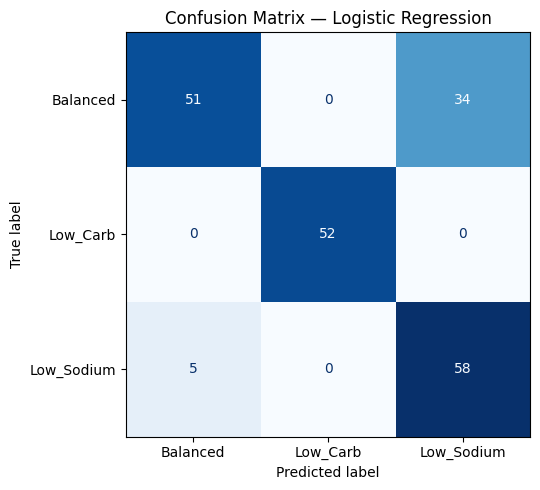

In [ ]:
# ── 5. CONFUSION MATRIX ──────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()


5-Fold Cross-Validation Scores: [0.75   0.7875 0.7438 0.8    0.8125]
Mean CV Accuracy : 0.7787 (77.88%)
Std Dev          : 0.0273


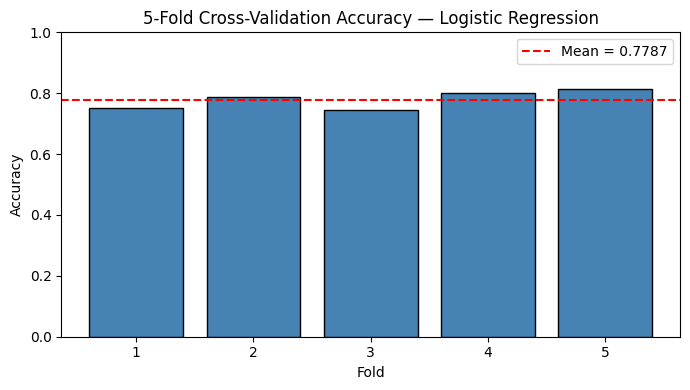

In [ ]:
# ── 6. CROSS-VALIDATION (overfitting check) ──────────────────
# 5-fold cross-validation gives a more reliable accuracy estimate
cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"\n5-Fold Cross-Validation Scores: {np.round(cv_scores, 4)}")
print(f"Mean CV Accuracy : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"Std Dev          : {cv_scores.std():.4f}")

# Visualize CV scores
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.title("5-Fold Cross-Validation Accuracy — Logistic Regression")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── 1. TRAIN RANDOM FOREST ───────────────────────────────────
# n_estimators=100  → 100 decision trees in the forest (good default)
# random_state=42   → reproducible results
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully")

✅ Random Forest model trained successfully


In [ ]:
# ── 2. PREDICTIONS ───────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test)


In [ ]:
# ── 3. EVALUATION METRICS ────────────────────────────────────
train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train))
test_acc_rf  = accuracy_score(y_test, y_pred_rf)

print(f"\nTraining Accuracy : {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")
print(f"Testing  Accuracy : {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")


Training Accuracy : 1.0000 (100.00%)
Testing  Accuracy : 0.7650 (76.50%)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,        # limits how deep each tree grows
    min_samples_leaf=5,  # each leaf must have at least 5 samples
    random_state=42
)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, min_samples_leaf=5, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)


train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train))
test_acc_rf  = accuracy_score(y_test, y_pred_rf)

print(f"\nTraining Accuracy : {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")
print(f"Testing  Accuracy : {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")


Training Accuracy : 0.9587 (95.88%)
Testing  Accuracy : 0.7950 (79.50%)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,        # limits how deep each tree grows
    min_samples_leaf=5,  # each leaf must have at least 5 samples
    random_state=42
)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, min_samples_leaf=5, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)


train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train))
test_acc_rf  = accuracy_score(y_test, y_pred_rf)

print(f"\nTraining Accuracy : {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")
print(f"Testing  Accuracy : {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")


Training Accuracy : 0.9587 (95.88%)
Testing  Accuracy : 0.7950 (79.50%)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,        # limits how deep each tree grows
    min_samples_leaf=10,  # each leaf must have at least 5 samples
    random_state=42
)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=8, min_samples_leaf=10, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)


train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train))
test_acc_rf  = accuracy_score(y_test, y_pred_rf)

print(f"\nTraining Accuracy : {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")
print(f"Testing  Accuracy : {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")


Training Accuracy : 0.8888 (88.88%)
Testing  Accuracy : 0.7800 (78.00%)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,        # limits how deep each tree grows
    min_samples_leaf=10,  # each leaf must have at least 5 samples
    random_state=42
)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=6, min_samples_leaf=10, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)


train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train))
test_acc_rf  = accuracy_score(y_test, y_pred_rf)

print(f"\nTraining Accuracy : {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")
print(f"Testing  Accuracy : {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")


Training Accuracy : 0.8413 (84.12%)
Testing  Accuracy : 0.8100 (81.00%)


In [ ]:
# Detailed per-class metrics
target_names = ['Balanced', 'Low_Carb', 'Low_Sodium']  # matches LabelEncoder order
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=target_names))


Classification Report:
              precision    recall  f1-score   support

    Balanced       0.96      0.58      0.72        85
    Low_Carb       1.00      1.00      1.00        52
  Low_Sodium       0.63      0.97      0.76        63

    accuracy                           0.81       200
   macro avg       0.86      0.85      0.83       200
weighted avg       0.87      0.81      0.81       200



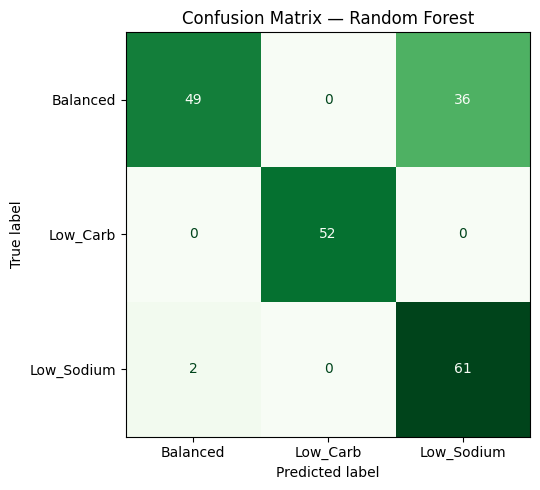

In [ ]:
# ── 4. CONFUSION MATRIX ──────────────────────────────────────

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=target_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()


5-Fold Cross-Validation Scores: [0.7688 0.7875 0.7938 0.8    0.8125]
Mean CV Accuracy : 0.7925 (79.25%)
Std Dev          : 0.0145


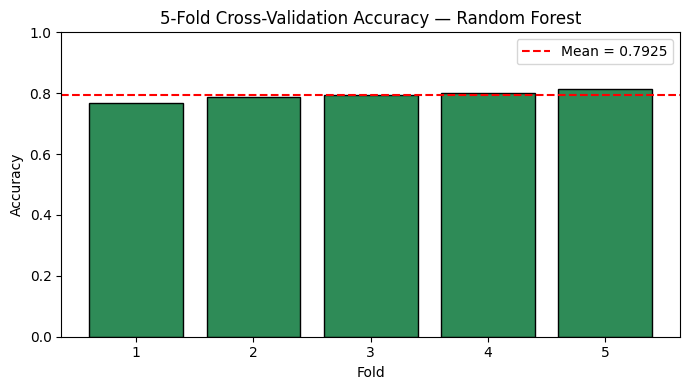

In [ ]:
# ── 5. CROSS-VALIDATION (overfitting check) ──────────────────
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"\n5-Fold Cross-Validation Scores: {np.round(cv_scores_rf, 4)}")
print(f"Mean CV Accuracy : {cv_scores_rf.mean():.4f} ({cv_scores_rf.mean()*100:.2f}%)")
print(f"Std Dev          : {cv_scores_rf.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores_rf, color='seagreen', edgecolor='black')
plt.axhline(cv_scores_rf.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores_rf.mean():.4f}')
plt.title("5-Fold Cross-Validation Accuracy — Random Forest")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 7. MODEL COMPARISON (LR vs RF) ───────────────────────────
# Compare both models side by side — great table for your paper
print("\n" + "="*45)
print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10}")
print("="*45)
print(f"{'Logistic Regression':<25} {train_acc:>10.4f} {test_acc:>10.4f}")
print(f"{'Random Forest':<25} {train_acc_rf:>10.4f} {test_acc_rf:>10.4f}")
print("="*45)


Model                      Train Acc   Test Acc
Logistic Regression           0.8125     0.8050
Random Forest                 0.8413     0.8100


In [ ]:
import joblib

# Save both models
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("✅ Models saved successfully")

✅ Models saved successfully


In [ ]:
from google.colab import files
files.download('lr_model.pkl')
files.download('rf_model.pkl')
files.download('scaler.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>